In [1]:
#Import libraries and load dataset
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_curve, auc
from sklearn.naive_bayes import GaussianNB
from sklearn.tree import DecisionTreeClassifier
from sklearn.linear_model import LogisticRegression

In [3]:
#Load dataset and split data
# Load dataset
data = load_breast_cancer()

X = data.data
y = data.target

# Train test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42
)

In [4]:
#Train the 3 algorithms
# Initialize models
nb = GaussianNB()
dt = DecisionTreeClassifier(random_state=42)
lr = LogisticRegression(max_iter=5000)

# Train models
nb.fit(X_train, y_train)
dt.fit(X_train, y_train)
lr.fit(X_train, y_train)

# Predictions
nb_pred = nb.predict(X_test)
dt_pred = dt.predict(X_test)
lr_pred = lr.predict(X_test)

In [5]:
#Calculate performance metrics
def evaluate(y_true, y_pred):
    acc = accuracy_score(y_true, y_pred)
    error = 1 - acc
    prec = precision_score(y_true, y_pred)
    rec = recall_score(y_true, y_pred)
    f1 = f1_score(y_true, y_pred)

    return acc, error, prec, rec, f1

nb_metrics = evaluate(y_test, nb_pred)
dt_metrics = evaluate(y_test, dt_pred)
lr_metrics = evaluate(y_test, lr_pred)

In [6]:
#Comparative tabular results
results = pd.DataFrame({
    "Algorithm": ["Naive Bayes", "Decision Tree", "Logistic Regression"],
    "Accuracy": [nb_metrics[0], dt_metrics[0], lr_metrics[0]],
    "Error Rate": [nb_metrics[1], dt_metrics[1], lr_metrics[1]],
    "Precision": [nb_metrics[2], dt_metrics[2], lr_metrics[2]],
    "Recall": [nb_metrics[3], dt_metrics[3], lr_metrics[3]],
    "F1 Score": [nb_metrics[4], dt_metrics[4], lr_metrics[4]]
})

print(results)

             Algorithm  Accuracy  Error Rate  Precision    Recall  F1 Score
0          Naive Bayes  0.941520    0.058480   0.945455  0.962963  0.954128
1        Decision Tree  0.941520    0.058480   0.971154  0.935185  0.952830
2  Logistic Regression  0.976608    0.023392   0.981481  0.981481  0.981481


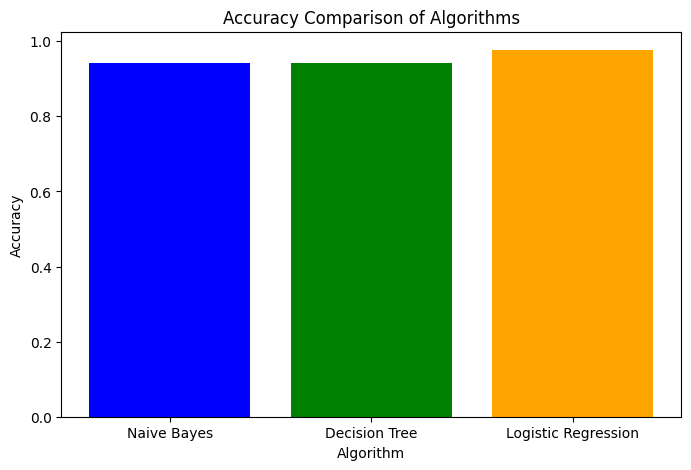

In [7]:
#Bar Chart Visualization
plt.figure(figsize=(8,5))

algorithms = results["Algorithm"]
accuracy = results["Accuracy"]

plt.bar(algorithms, accuracy, color=["blue","green","orange"])

plt.title("Accuracy Comparison of Algorithms")
plt.ylabel("Accuracy")
plt.xlabel("Algorithm")

plt.show()

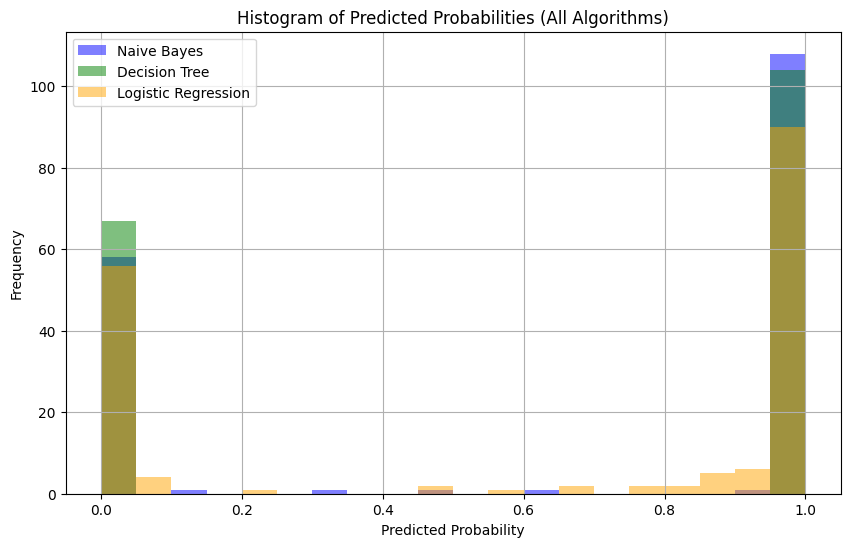

In [10]:
#Histogram Visualization
plt.figure(figsize=(10,6))

# Predicted probabilities for class 1
nb_prob = nb.predict_proba(X_test)[:,1]
dt_prob = dt.predict_proba(X_test)[:,1]
lr_prob = lr.predict_proba(X_test)[:,1]

# Plot histograms
plt.hist(nb_prob, bins=20, alpha=0.5, label="Naive Bayes", color="blue")
plt.hist(dt_prob, bins=20, alpha=0.5, label="Decision Tree", color="green")
plt.hist(lr_prob, bins=20, alpha=0.5, label="Logistic Regression", color="orange")

plt.title("Histogram of Predicted Probabilities (All Algorithms)")
plt.xlabel("Predicted Probability")
plt.ylabel("Frequency")

plt.legend()
plt.grid(True)

plt.show()

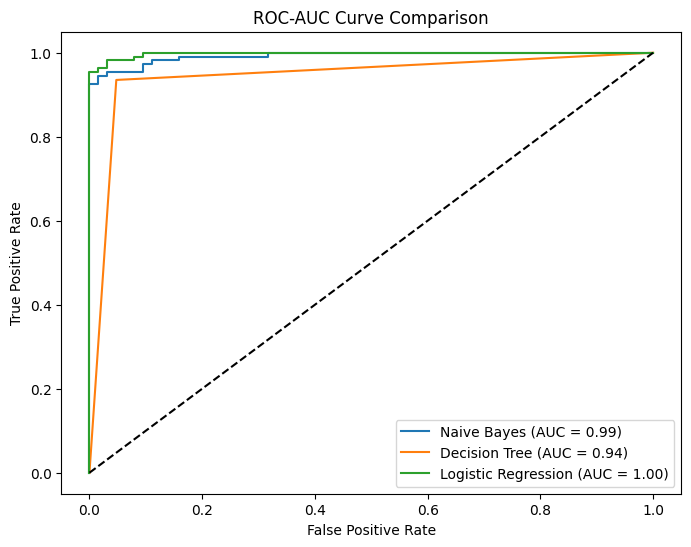

In [9]:
#ROC-AUC Curve
# Probabilities
nb_prob = nb.predict_proba(X_test)[:,1]
dt_prob = dt.predict_proba(X_test)[:,1]
lr_prob = lr.predict_proba(X_test)[:,1]

# ROC values
nb_fpr, nb_tpr, _ = roc_curve(y_test, nb_prob)
dt_fpr, dt_tpr, _ = roc_curve(y_test, dt_prob)
lr_fpr, lr_tpr, _ = roc_curve(y_test, lr_prob)

# AUC scores
nb_auc = auc(nb_fpr, nb_tpr)
dt_auc = auc(dt_fpr, dt_tpr)
lr_auc = auc(lr_fpr, lr_tpr)

plt.figure(figsize=(8,6))

plt.plot(nb_fpr, nb_tpr, label="Naive Bayes (AUC = %0.2f)" % nb_auc)
plt.plot(dt_fpr, dt_tpr, label="Decision Tree (AUC = %0.2f)" % dt_auc)
plt.plot(lr_fpr, lr_tpr, label="Logistic Regression (AUC = %0.2f)" % lr_auc)

plt.plot([0,1],[0,1],'k--')

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC-AUC Curve Comparison")

plt.legend()
plt.show()